# Applications in mathematical morphology

In [1]:
import numpy as np
import skimage.io as io
import skimage.morphology as mo
import matplotlib.pyplot as plt

## Top-hat

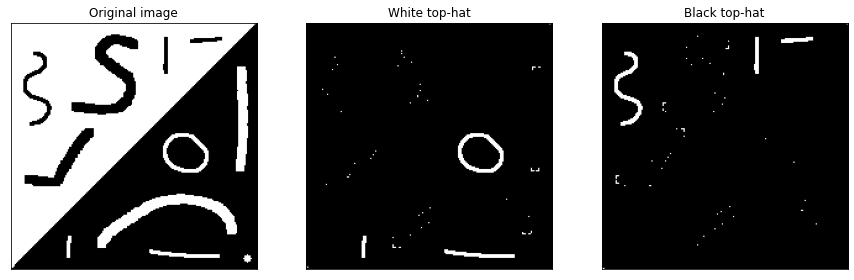

In [4]:
# Image
img = io.imread("vermicelli.png")/255

# Structuring element
E = mo.disk(3)

# Add the structuring element in the image
N = E.shape[0]
d = 5
img[-N-d:-d,-N-d:-d] = E

# White top-hat
Tw = img - mo.binary_opening(img,E).astype(np.uint8)
  
# Black top-hat
Tb = mo.binary_closing(img,E).astype(np.uint8) - img

# Affichage
fig, axs = plt.subplots(1,3,figsize=(15,5))
axs[0].imshow(img, "gray")
axs[0].set_title("Original image")
axs[1].imshow(Tw, "gray")
axs[1].set_title("White top-hat")
axs[2].imshow(Tb, "gray")
axs[2].set_title("Black top-hat")
for i in range(3):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig("top-hat.svg", bbox_inches='tight')
plt.show()

## Granulometry

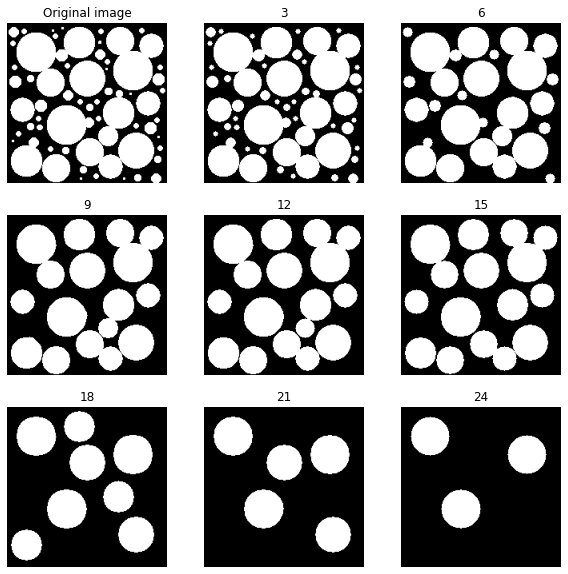

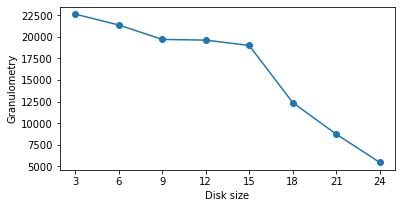

In [3]:
# Image
img = io.imread("grains2.png")
N = img.shape[0]

# Élément structurant de base
E = mo.disk(3)

# Nombre d'étapes
K = 8

# Ouvertures successives
res = [np.zeros((N,N,K))] * K
granulometry = np.zeros(K)
size = np.zeros(K, dtype=np.int8)
for k in range(K):

    # Élément structurant
    # if k == 0:
    #     Ek = np.pad(E, 15)
    # else:
    #     Ek = mo.binary_dilation(Ek,E)
    size[k] = 3*(k+1)
    Ek = mo.disk(size[k])

    # Ouverture
    res[k] = mo.binary_opening(img,Ek)
    
    # Calcul de la granulométrie
    granulometry[k] = np.sum(res[k].ravel())

# Affichage des images
fig, axs = plt.subplots(3,3, figsize=(10,10))
axs = axs.ravel()
axs[0].imshow(img, "gray")
axs[0].set_title("Original image")
for k in range(K):
    axs[k+1].imshow(res[k], "gray")
    axs[k+1].set_title(f"{size[k]}")
for k in range(K+1):
    axs[k].axis("off")
plt.savefig("granulometry-images.svg", bbox_inches='tight')
plt.show()

# Affichage de la granulométrie et de sa distribution
fig = plt.figure(figsize=(6,3))
plt.plot(size, granulometry, '-o')
plt.xticks(size)
plt.xlabel("Disk size")
plt.ylabel("Granulometry")
plt.savefig("granulometry-plot.svg", bbox_inches='tight')
plt.show()

## Skeleton

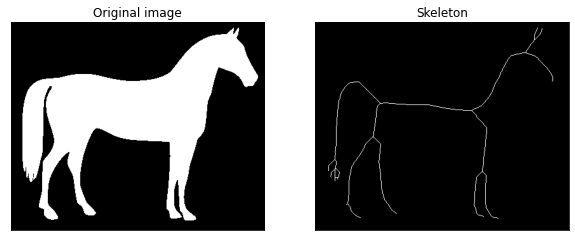

In [16]:
import skimage.data as data

img = 1 - data.horse()
sk = mo.skeletonize(img)

# Affichage
fig, axs = plt.subplots(1,2,figsize=(10,5))
axs[0].imshow(img, "gray")
axs[0].set_title("Original image")
axs[1].imshow(sk, "gray")
axs[1].set_title("Skeleton")
for i in range(2):
    axs[i].set_xticks([])
    axs[i].set_yticks([])
plt.savefig("skeleton.svg", bbox_inches='tight')
plt.show()